In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

In [5]:
# constants

g = 9.81
rho = 1.225

mass_kg = 50
thrust_newton = 1500
drag_coeff = 0.5
area = 0.1

y0 = 0.0
v0 = 0.0
t_max = 20
dt = 0.01

In [6]:
time_stamps = np.arange(0, t_max, dt)

y = np.zeros_like(time_stamps)
v = np.zeros_like(time_stamps)

y[0] = y0
v[0] = v0

In [9]:
for i in range(1, len(time_stamps)):
    drag = 0.5 * rho * drag_coeff * area * v[i-1]**2
    drag *= -np.sign(v[i-1])

    f_net = thrust_newton - (mass_kg * g) + drag
    a = f_net / mass_kg

    v[i] = v[i-1] + a*dt
    y[i] = y[i-1] + v[i]*dt

    if y[i] < 0:
        y[i] = 0
        v[i] = 0
        time_stamps = time_stamps[:i+1]
        y = y[:i+1]
        v = v[:i+1]
        break


Text(0, 0.5, 'Altitude (m)')

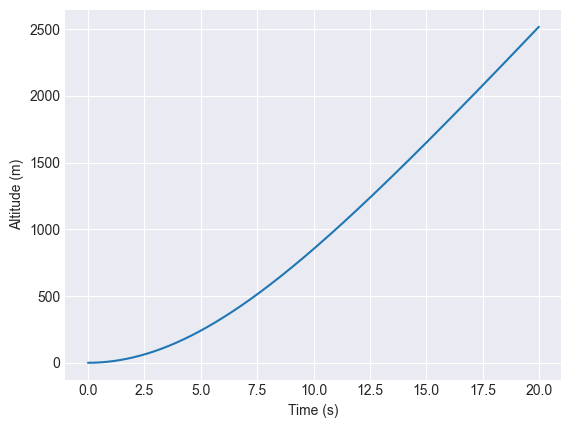

In [12]:
plt.plot(time_stamps, y)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")

Text(0, 0.5, 'Velocity (m/s)')

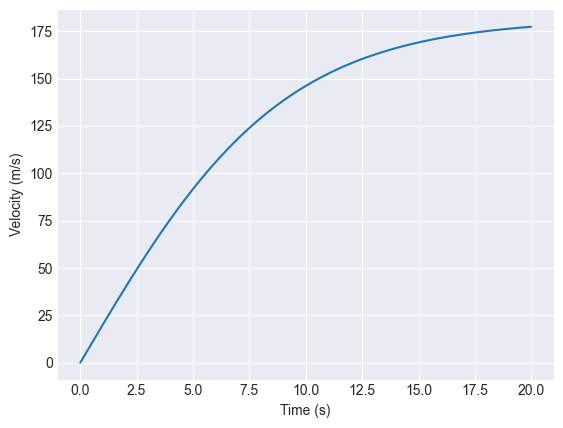

In [14]:
plt.plot(time_stamps, v)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")